# Deep Learning (Foundation Models) — Proof of Concept

This notebook runs **expanding-window backtests** on hourly Czech gas consumption
(2013–2025) using **pretrained foundation models**:

- `amazon/chronos-2` (Chronos-2)
- `time-series-foundation-models/Lag-Llama`
- `Salesforce/moirai-1.0-R-base`

Workflow:
1) **Zero-shot** inference with author weights
2) **Training / fine-tuning** on your data (minimal POC)

Outputs:
- No plots. Only **pandas DataFrames**.
- Metrics: **SMAPE**, **MAE**, **MSE**, **R²**.
- Special focus: **Russia–Ukraine conflict** (`2022-02-24`) via pre/post slices.


In [10]:
from __future__ import annotations

# Work around matplotlib 3.10 + torchmetrics:
# - Force a stable backend (Jupyter may set MPLBACKEND to an unsupported value)
# - Ensure torchmetrics can access `matplotlib.colors` as an attribute
import matplotlib as _mpl
import matplotlib.colors as _mpl_colors

# Some environments don't expose submodules as attributes on the top-level package.
# Torchmetrics expects `matplotlib.colors` to exist, so we attach it explicitly.
_mpl.colors = _mpl_colors

from collections.abc import Iterable
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from huggingface_hub import hf_hub_download

DATA_PATH = (
    Path("..") / "data" / "preprocessed" / "merged_all_years_preprocessed.csv"
).resolve()

TARGET_COL = "consumption_total"

PREDICTION_LENGTH = 24  # hours ahead
WINDOW_STRIDE = 24  # evaluate 1x per day; set to 1 for full hourly rolling

MAX_CONTEXT_LENGTH = 2048  # cap for speed + model limits

CONFLICT_DATE = pd.Timestamp("2022-02-24 00:00:00")
TZ = None  # data is already in local calendar time; keep naive timestamps

SEED = 42
np.random.seed(SEED)

SHOW_PROGRESS = True

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 200)

In [11]:
# Diagnostic: confirm matplotlib behaves for torchmetrics/lightning imports
import matplotlib

print(
    "matplotlib:", matplotlib.__version__, "has colors:", hasattr(matplotlib, "colors")
)
try:
    import matplotlib.colors as _mc

    print("matplotlib.colors import ok:", _mc.Colormap)
except Exception as _exc:
    print("matplotlib.colors import FAILED:", type(_exc).__name__, _exc)

matplotlib: 3.10.8 has colors: True
matplotlib.colors import ok: <class 'matplotlib.colors.Colormap'>


In [12]:
def build_timestamp(df: pd.DataFrame) -> pd.Series:
    ts = pd.to_datetime(df[["year", "month", "day", "hour"]], errors="coerce")
    if TZ is not None:
        ts = ts.dt.tz_localize(TZ)
    return ts


def dedupe_by_timestamp(df: pd.DataFrame, timestamp_col: str) -> pd.DataFrame:
    if df[timestamp_col].isna().any():
        raise ValueError("Found NaT timestamps; fix parsing before de-duping.")

    dup_count = int(df.duplicated(timestamp_col).sum())
    if dup_count == 0:
        return df

    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

    agg: dict[str, str] = {c: "mean" for c in numeric_cols}
    for c in ["holiday", "before_holiday", "day_of_week", "weather_code"]:
        if c in agg:
            agg[c] = "max"

    out = (
        df.groupby(timestamp_col, as_index=False)
        .agg(agg)
        .sort_values(timestamp_col, kind="stable")
        .reset_index(drop=True)
    )
    return out


def interpolate_small_gaps(s: pd.Series, limit: int = 6) -> pd.Series:
    out = s.copy()
    out = out.interpolate(method="linear", limit=limit, limit_direction="both")
    out = out.ffill().bfill()
    return out


df_raw = pd.read_csv(DATA_PATH)
df_raw["timestamp"] = build_timestamp(df_raw)

df = (
    df_raw.drop(columns=["year", "month", "day", "hour"])
    .sort_values("timestamp", kind="stable")
    .reset_index(drop=True)
)

df = dedupe_by_timestamp(df, timestamp_col="timestamp")

missing_before = int(df[TARGET_COL].isna().sum())
df[TARGET_COL] = interpolate_small_gaps(df[TARGET_COL], limit=6)
missing_after = int(df[TARGET_COL].isna().sum())

print("rows:", len(df))
print("timestamp min/max:", df["timestamp"].min(), df["timestamp"].max())
print("target missing before/after:", missing_before, missing_after)

rows: 113952
timestamp min/max: 2013-01-01 00:00:00 2025-12-31 23:00:00
target missing before/after: 0 0


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def smape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.maximum(denom, 1e-8)
    return float(200.0 * np.mean(np.abs(y_pred - y_true) / denom))


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    return {
        "smape": smape(y_true, y_pred),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "mse": float(mean_squared_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


def year_bounds(year: int) -> tuple[pd.Timestamp, pd.Timestamp]:
    start = pd.Timestamp(datetime(year, 1, 1))
    end = pd.Timestamp(datetime(year + 1, 1, 1))
    return start, end


def iter_test_origins(test_df: pd.DataFrame) -> Iterable[int]:
    max_i = len(test_df) - PREDICTION_LENGTH
    i = 0
    while i <= max_i:
        yield i
        i += WINDOW_STRIDE

In [14]:
import torch
from gluonts.dataset.common import ListDataset
from gluonts.torch.distributions.studentT import StudentTOutput
from gluonts.torch.modules.loss import NegativeLogLikelihood
from lag_llama.gluon.estimator import LagLlamaEstimator
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule


@dataclass(frozen=True)
class ForecastResult:
    y_pred: np.ndarray


class BaseForecaster:
    name: str
    mode: str

    def forecast(self, context: np.ndarray) -> ForecastResult:
        raise NotImplementedError


class Chronos2Forecaster(BaseForecaster):
    def __init__(
        self,
        repo_id: str = "amazon/chronos-2",
        device: str = "auto",
        num_samples: int = 21,
    ) -> None:
        from chronos import Chronos2Pipeline

        if device == "auto":
            device = "cuda" if torch.cuda.is_available() else "cpu"

        self.name = "chronos-2"
        self.mode = "pretrained"
        self._pipe = Chronos2Pipeline.from_pretrained(repo_id)
        self._pipe.model.to(device)  # type: ignore
        self._num_samples = num_samples

    def forecast(self, context: np.ndarray) -> ForecastResult:
        x = np.asarray(context, dtype=np.float32)
        x = x[-MAX_CONTEXT_LENGTH:]
        x3 = x[None, None, :]

        with torch.no_grad():
            out = self._pipe.predict(
                x3,
                prediction_length=PREDICTION_LENGTH,
                batch_size=1,
                context_length=min(len(x), MAX_CONTEXT_LENGTH),
            )

        samples = out[0][0]
        y_pred = samples.float().mean(dim=0).cpu().numpy()
        return ForecastResult(y_pred=y_pred)


def _patch_lag_llama_lags_handling() -> None:
    import lag_llama.gluon.estimator as ll_est

    orig_fn = ll_est.get_lags_for_frequency

    def patched_get_lags_for_frequency(freq_str, *args, **kwargs):
        if isinstance(freq_str, int):
            # LagLlamaEstimator later subtracts 1 from lag indices.
            # Returning (lag + 1) preserves the intended lag.
            return [freq_str + 1]
        return orig_fn(freq_str=freq_str, *args, **kwargs)

    ll_est.get_lags_for_frequency = patched_get_lags_for_frequency


class LagLlamaForecaster(BaseForecaster):
    def __init__(
        self,
        ckpt_path: str,
        freq: str = "h",
        device: torch.device | None = None,
    ) -> None:
        self.name = "lag-llama"
        self.mode = "pretrained"

        if device is None:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self._freq = freq
        self._device = device
        self._ckpt_path = ckpt_path

        torch.serialization.add_safe_globals([StudentTOutput, NegativeLogLikelihood])

        ckpt_obj = torch.load(
            self._ckpt_path,
            map_location="cpu",
            weights_only=False,
        )
        model_kwargs = ckpt_obj["hyper_parameters"]["model_kwargs"]
        lags_seq = [int(v) for v in model_kwargs["lags_seq"]]

        _patch_lag_llama_lags_handling()

        self._estimator = LagLlamaEstimator(
            prediction_length=PREDICTION_LENGTH,
            context_length=int(model_kwargs["context_length"]),
            input_size=int(model_kwargs["input_size"]),
            n_layer=int(model_kwargs["n_layer"]),
            n_head=int(model_kwargs["n_head"]),
            n_embd_per_head=int(model_kwargs["n_embd_per_head"]),
            scaling=str(model_kwargs.get("scaling", "robust")),
            time_feat=bool(model_kwargs.get("time_feat", True)),
            dropout=float(model_kwargs.get("dropout", 0.0)),
            # Avoid Lightning's load_from_checkpoint path (can break across Lightning versions).
            # We'll instantiate the module directly and load the ckpt state_dict manually.
            ckpt_path=None,
            device=self._device,
            batch_size=1,
            num_parallel_samples=20,
            lags_seq=lags_seq,
            use_single_pass_sampling=True,
        )

        transformation = self._estimator.create_transformation()
        module = self._estimator.create_lightning_module(use_kv_cache=True)

        state_dict = ckpt_obj.get("state_dict")
        if state_dict is None:
            raise KeyError("Lag-Llama checkpoint missing state_dict")

        # Lightning checkpoints often prefix weights with 'model.' etc. strict=False is expected.
        module.load_state_dict(state_dict, strict=False)
        module.to(self._device)
        module.eval()

        self._predictor = self._estimator.create_predictor(transformation, module)

    def forecast(self, context: np.ndarray) -> ForecastResult:
        x = np.asarray(context, dtype=np.float32)
        x = x[-MAX_CONTEXT_LENGTH:]

        start = pd.Timestamp(df["timestamp"].iloc[0])
        if len(x) != len(context):
            start = start + pd.Timedelta(hours=len(context) - len(x))

        dataset = ListDataset(
            [{"start": start, "target": x}],
            freq=self._freq,
            one_dim_target=True,
        )
        fcst = next(iter(self._predictor.predict(dataset)))
        y_pred = np.asarray(fcst.samples, dtype=np.float32).mean(axis=0)  # type: ignore
        return ForecastResult(y_pred=y_pred)


class MoiraiForecaster(BaseForecaster):
    def __init__(
        self,
        repo_id: str = "Salesforce/moirai-1.0-R-base",
        freq: str = "h",
        device: str = "auto",
    ) -> None:
        self.name = "moirai-1.0-R-base"
        self.mode = "pretrained"

        self._freq = freq
        self._module = MoiraiModule.from_pretrained(repo_id)
        self._forecast = MoiraiForecast(
            prediction_length=PREDICTION_LENGTH,
            target_dim=1,
            feat_dynamic_real_dim=0,
            past_feat_dynamic_real_dim=0,
            context_length=min(MAX_CONTEXT_LENGTH, 168),
            module=self._module,
            num_samples=20,
        )
        self._predictor = self._forecast.create_predictor(batch_size=32, device=device)

    def forecast(self, context: np.ndarray) -> ForecastResult:
        x = np.asarray(context, dtype=np.float32)
        x = x[-MAX_CONTEXT_LENGTH:]

        start = pd.Timestamp(df["timestamp"].iloc[0])
        if len(x) != len(context):
            start = start + pd.Timedelta(hours=len(context) - len(x))

        dataset = ListDataset(
            [{"start": start, "target": x}],
            freq=self._freq,
            one_dim_target=True,
        )
        fcst = next(iter(self._predictor.predict(dataset)))
        y_pred = np.asarray(fcst.samples, dtype=np.float32).mean(axis=0)  # type: ignore
        return ForecastResult(y_pred=y_pred)


class TimesFMForecaster(BaseForecaster):
    def __init__(
        self,
        repo_id: str = "google/timesfm-1.0-200m-pytorch",
        freq_type: int = 0,
        context_len: int = 512,
        horizon_len: int = 128,
        per_core_batch_size: int = 1,
    ) -> None:
        # TimesFM v1 expects contiguous contexts; our preprocessing fills gaps already.
        self.name = "timesfm-1.0-200m-pytorch"
        self.mode = "pretrained"
        self._freq_type = int(freq_type)
        self._context_len = int(context_len)
        self._horizon_len = int(horizon_len)

        try:
            import timesfm  # type: ignore
        except Exception as exc:
            raise ImportError(
                'TimesFM is not installed. With uv, run: uv add "timesfm[torch]==1.3.0"'
            ) from exc

        backend = "gpu" if torch.cuda.is_available() else "cpu"
        self._tfm = timesfm.TimesFm(
            hparams=timesfm.TimesFmHparams(
                backend=backend,
                per_core_batch_size=per_core_batch_size,
                horizon_len=self._horizon_len,
                context_len=self._context_len,
            ),
            checkpoint=timesfm.TimesFmCheckpoint(huggingface_repo_id=repo_id),
        )

    def forecast(self, context: np.ndarray) -> ForecastResult:
        x = np.asarray(context, dtype=np.float32)
        # In our evaluation setup context is always long enough; truncate for model limits.
        x = x[-self._context_len :]
        if np.isnan(x).any():
            raise ValueError("TimesFM requires contiguous contexts (no NaNs).")

        point_fcst, _ = self._tfm.forecast([x], freq=[self._freq_type])
        y = np.asarray(point_fcst[0], dtype=np.float32)
        y_pred = y[:PREDICTION_LENGTH]
        return ForecastResult(y_pred=y_pred)


def download_lag_llama_ckpt() -> str:
    return hf_hub_download(
        repo_id="time-series-foundation-models/Lag-Llama",
        filename="lag-llama.ckpt",
    )

In [15]:
import warnings

from tqdm import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=r"Using a non-tuple sequence for multidimensional indexing.*",
)


def evaluate_forecaster(
    forecaster: BaseForecaster,
    test_years: Iterable[int],
    max_origins_per_year: int | None = None,
) -> pd.DataFrame:
    rows: list[dict[str, object]] = []

    full_series = df[["timestamp", TARGET_COL]].copy()

    for test_year in test_years:
        train_end_year = test_year - 1
        train_label = f"2013-{train_end_year}"

        start, end = year_bounds(test_year)
        test_df = full_series[
            (full_series["timestamp"] >= start) & (full_series["timestamp"] < end)
        ].reset_index(drop=True)

        seg_true: dict[str, list[np.ndarray]] = {
            "all": [],
            "pre_conflict": [],
            "post_conflict": [],
        }
        seg_pred: dict[str, list[np.ndarray]] = {
            "all": [],
            "pre_conflict": [],
            "post_conflict": [],
        }
        seg_windows: dict[str, int] = {
            "all": 0,
            "pre_conflict": 0,
            "post_conflict": 0,
        }

        origins = list(iter_test_origins(test_df))
        if max_origins_per_year is not None:
            origins = origins[:max_origins_per_year]

        for i in tqdm(origins, desc=f"{forecaster.name} {test_year}", leave=True):
            origin_ts = pd.Timestamp(test_df["timestamp"].iloc[i])

            context = full_series[full_series["timestamp"] < origin_ts][
                TARGET_COL
            ].to_numpy(dtype=np.float32)

            y_true = (
                test_df[TARGET_COL]
                .iloc[i : i + PREDICTION_LENGTH]
                .to_numpy(dtype=np.float32)
            )

            y_pred = forecaster.forecast(context).y_pred
            if len(y_pred) != len(y_true):
                raise ValueError(
                    f"Bad forecast length: got {len(y_pred)} expected {len(y_true)}"
                )

            seg = "post_conflict" if origin_ts >= CONFLICT_DATE else "pre_conflict"

            seg_true["all"].append(y_true)
            seg_pred["all"].append(y_pred)
            seg_windows["all"] += 1

            seg_true[seg].append(y_true)
            seg_pred[seg].append(y_pred)
            seg_windows[seg] += 1

        for seg in ["all", "pre_conflict", "post_conflict"]:
            if seg_windows[seg] == 0:
                continue

            y_true_all = np.concatenate(seg_true[seg])
            y_pred_all = np.concatenate(seg_pred[seg])
            m = compute_metrics(y_true_all, y_pred_all)

            rows.append(
                {
                    "model": forecaster.name,
                    "mode": forecaster.mode,
                    "train_years": train_label,
                    "test_year": test_year,
                    "segment": seg,
                    "n_windows": seg_windows[seg],
                    "n_points": int(y_true_all.size),
                    **m,
                }
            )

    return pd.DataFrame(rows)


def add_period_column(results: pd.DataFrame) -> pd.DataFrame:
    out = results.copy()
    out["period"] = np.where(out["test_year"] >= 2022, "post", "pre")
    return out


def patch_lagged_sequence_values_for_lag_llama() -> None:
    import gluonts.torch.util as gtu
    import lag_llama.model.module as ll_module
    import torch
    from gluonts.torch.util import slice_along_dim

    def stable_lagged_sequence_values(
        indices: list[int],
        prior_sequence: torch.Tensor,
        sequence: torch.Tensor,
        dim: int,
    ) -> torch.Tensor:
        seq_len = int(sequence.shape[dim])
        if seq_len <= 0:
            raise ValueError(f"sequence length must be > 0, got {seq_len}")

        full_sequence = torch.cat((prior_sequence, sequence), dim=dim)
        full_len = int(full_sequence.shape[dim])

        lags_values: list[torch.Tensor] = []
        for lag_index in indices:
            lag = int(lag_index)
            if lag < 0:
                raise ValueError(f"negative lag is not supported: {lag}")

            end = full_len - lag
            start = end - seq_len
            lags_values.append(
                slice_along_dim(full_sequence, dim=dim, slice_=slice(start, end))
            )

        return torch.stack(lags_values, dim=-1)

    gtu.lagged_sequence_values = stable_lagged_sequence_values
    ll_module.lagged_sequence_values = stable_lagged_sequence_values

In [16]:
RUN_CHRONOS = True
RUN_LAG_LLAMA = True
RUN_MOIRAI = True
RUN_TIMESFM = True

SMOKE_TEST = False
TEST_YEARS = list(range(2014, 2026))
MAX_ORIGINS_PER_YEAR = 2 if SMOKE_TEST else None

In [17]:
if RUN_LAG_LLAMA:
    patch_lagged_sequence_values_for_lag_llama()

forecasters: list[BaseForecaster] = []
if RUN_CHRONOS:
    forecasters.append(Chronos2Forecaster())

if RUN_LAG_LLAMA:
    ckpt_path = download_lag_llama_ckpt()
    forecasters.append(LagLlamaForecaster(ckpt_path=ckpt_path))

if RUN_MOIRAI:
    forecasters.append(MoiraiForecaster())

if RUN_TIMESFM:
    forecasters.append(TimesFMForecaster())

Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 43539.49it/s]


In [18]:
frames: list[pd.DataFrame] = []
for forecaster in forecasters:
    try:
        frames.append(
            evaluate_forecaster(
                forecaster,
                test_years=TEST_YEARS,
                max_origins_per_year=MAX_ORIGINS_PER_YEAR,
            )
        )
    except Exception as exc:
        print(f"FAILED: {forecaster.name} ({type(exc).__name__}: {exc})")

timesfm-1.0-200m-pytorch 2025: 100%|██████████| 365/365 [00:03<00:00, 102.18it/s]


In [19]:
if not frames:
    raise RuntimeError("All model runs failed; see errors above.")

all_results = pd.concat(frames, ignore_index=True)
all_results = add_period_column(all_results)

print("Per-year results (segment=all):")
print(
    all_results[all_results["segment"] == "all"]
    .sort_values(["model", "mode", "test_year"])
    .reset_index(drop=True)
)

Per-year results (segment=all):
                       model        mode train_years  test_year segment  n_windows  n_points     smape           mae           mse        r2 period
0                  chronos-2  pretrained   2013-2013       2014     all        365      8760  4.663106  32754.628699  2.548292e+09  0.978325    pre
1                  chronos-2  pretrained   2013-2014       2015     all        365      8760  4.790813  33651.755574  2.588543e+09  0.979835    pre
2                  chronos-2  pretrained   2013-2015       2016     all        366      8784  5.213132  40017.806660  5.628747e+09  0.962737    pre
3                  chronos-2  pretrained   2013-2016       2017     all        365      8760  4.739294  36059.086043  2.888078e+09  0.983624    pre
4                  chronos-2  pretrained   2013-2017       2018     all        365      8760  4.402598  32135.915609  2.310465e+09  0.987550    pre
5                  chronos-2  pretrained   2013-2018       2019     all        3

In [20]:
print("\nConflict slice (window start vs 2022-02-24):")
conflict_table = (
    all_results[all_results["segment"].isin(["pre_conflict", "post_conflict"])]
    .groupby(["model", "mode", "period", "segment"], as_index=False)
    .agg(
        smape=("smape", "mean"),
        mae=("mae", "mean"),
        mse=("mse", "mean"),
        r2=("r2", "mean"),
        n_windows=("n_windows", "sum"),
        n_points=("n_points", "sum"),
    )
    .sort_values(["model", "mode", "period", "segment"])
)
display(conflict_table)


Conflict slice (window start vs 2022-02-24):


,model,mode,period,segment,smape,mae,mse,r2,n_windows,n_points
0,chronos-2,pretrained,post,post_conflict,4.583231,28813.648318,1.888594e+09,0.982278,1407,33768
1,chronos-2,pretrained,post,pre_conflict,3.518648,39865.451244,2.997433e+09,0.943731,54,1296
2,chronos-2,pretrained,pre,pre_conflict,4.737962,35538.781571,3.121460e+09,0.978914,2922,70128
3,lag-llama,pretrained,post,post_conflict,7.437450,47552.351278,4.875279e+09,0.954342,1407,33768
4,lag-llama,pretrained,post,pre_conflict,5.390183,61886.958574,6.842733e+09,0.871545,54,1296
5,lag-llama,pretrained,pre,pre_conflict,7.424382,56608.250788,7.105581e+09,0.952299,2922,70128
6,moirai-1.0-R-base,pretrained,post,post_conflict,7.605687,47493.812200,4.961882e+09,0.953598,1407,33768
7,moirai-1.0-R-base,pretrained,post,pre_conflict,5.895255,68528.648823,7.953400e+09,0.850695,54,1296
8,moirai-1.0-R-base,pretrained,pre,pre_conflict,7.411874,55580.399482,6.914483e+09,0.953382,2922,70128
9,timesfm-1.0-200m-pytorch,pretrained,post,post_conflict,5.589733,35670.579131,2.861077e+09,0.973175,1407,33768


In [21]:
print("\nSide-by-side (SMAPE) per test year:")
smape_pivot = (
    all_results[all_results["segment"] == "all"]
    .pivot_table(
        index="test_year",
        columns=["model", "mode"],
        values="smape",
        aggfunc="mean",
    )
    .sort_index()
)
display(smape_pivot)


Side-by-side (SMAPE) per test year:


model,chronos-2,lag-llama,moirai-1.0-R-base,timesfm-1.0-200m-pytorch
mode,pretrained,pretrained,pretrained,pretrained
test_year,,,,
2014,4.663106,7.370755,7.637390,5.720853
2015,4.790813,7.234996,7.264089,5.529760
2016,5.213132,8.194035,8.312173,6.168852
2017,4.739294,7.438203,7.535140,5.743843
2018,4.402598,7.343280,7.126273,5.150562
2019,4.883177,7.503794,7.499771,5.966464
2020,4.814823,7.412552,7.263973,5.930097
2021,4.396757,6.897438,6.656180,5.339025


In [22]:
# Fine-tuning configuration (small POC)

RUN_CHRONOS_FINETUNE = True
RUN_LAG_LLAMA_FINETUNE = True
RUN_MOIRAI_FINETUNE = True
RUN_TIMESFM_FINETUNE = True

# Full expanding-window run (2014..2025).
SMOKE_TEST_FINETUNE = False
TEST_YEARS_FINETUNED = list(range(2014, 2026))

# Keep this small; full run does 12 folds (2014..2025).
FINE_TUNE_MAX_EPOCHS = 1
FINE_TUNE_LR = 5e-5

# Optional speed knob: limit origins during fine-tuned evaluation.
# Set to None to match the full evaluation protocol (can take a long time).
FINE_TUNE_MAX_ORIGINS_PER_YEAR: int | None = 50

# For training, we sample random windows from the full train history.
FINE_TUNE_BATCH_SIZE = 8
FINE_TUNE_STEPS_PER_EPOCH = 50

In [23]:
# Quick sanity run toggle (keeps runtime short while validating new model integration)
QUICK_CHECK = False

if QUICK_CHECK:
    # Keep it very small for error-checking; switch QUICK_CHECK=False for full runs.
    TEST_YEARS = [2014]
    MAX_ORIGINS_PER_YEAR = 2

    TEST_YEARS_FINETUNED = [2014]
    FINE_TUNE_MAX_ORIGINS_PER_YEAR = 2
    FINE_TUNE_MAX_EPOCHS = 1
    FINE_TUNE_STEPS_PER_EPOCH = 2
    FINE_TUNE_BATCH_SIZE = 2

    print("QUICK_CHECK enabled: tiny run for validation")

In [24]:
def train_slice_end(train_end_year: int) -> pd.Timestamp:
    # Training data includes all timestamps strictly before Jan 1 of (train_end_year + 1).
    return pd.Timestamp(datetime(train_end_year + 1, 1, 1))


def make_train_target(train_end_year: int) -> np.ndarray:
    end = train_slice_end(train_end_year)
    return df.loc[df["timestamp"] < end, TARGET_COL].to_numpy(dtype=np.float32)


def make_gluonts_train_dataset(train_end_year: int, freq: str = "h") -> ListDataset:
    y = make_train_target(train_end_year)
    start = pd.Timestamp(df["timestamp"].iloc[0])
    return ListDataset(
        [{"start": start, "target": y}],
        freq=freq,
        one_dim_target=True,
    )

In [25]:
from torch.utils.data import DataLoader, Dataset


class RandomWindowDataset(Dataset):
    def __init__(
        self,
        series: np.ndarray,
        context_length: int,
        prediction_length: int,
        n_samples: int,
    ) -> None:
        self.series = np.asarray(series, dtype=np.float32)
        self.context_length = int(context_length)
        self.prediction_length = int(prediction_length)
        self.n_samples = int(n_samples)

        min_total = self.context_length + self.prediction_length
        if len(self.series) < min_total:
            raise ValueError(
                f"Need at least {min_total} points, " f"got {len(self.series)}"
            )

    def __len__(self) -> int:
        return self.n_samples

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        max_start = len(self.series) - (self.context_length + self.prediction_length)
        start = int(np.random.randint(0, max_start + 1))

        past = self.series[start : start + self.context_length]
        future = self.series[
            start
            + self.context_length : start
            + self.context_length
            + self.prediction_length
        ]

        context = torch.from_numpy(past)  # (context_len,)
        future_target = torch.from_numpy(future)  # (pred_len,)

        return {
            "context": context,
            "future_target": future_target,
        }

In [26]:
from chronos import Chronos2Model


class BaseForecaster:
    name: str
    mode: str

    def forecast(self, context: np.ndarray) -> ForecastResult:
        raise NotImplementedError


class Chronos2FineTunedForecaster(BaseForecaster):
    def __init__(
        self,
        model: Chronos2Model,
        device: torch.device,
    ) -> None:
        self.name = "chronos-2"
        self.mode = "finetuned"
        self._model = model
        self._device = device

        qs = self._model.chronos_config.quantiles
        self._q_index = int(np.argmin(np.abs(np.asarray(qs) - 0.5)))

    def forecast(self, context: np.ndarray) -> ForecastResult:
        x = np.asarray(context, dtype=np.float32)[-MAX_CONTEXT_LENGTH:]
        ctx = torch.from_numpy(x)[None, :].to(self._device)  # (b=1, t)

        output_patch_size = int(self._model.chronos_config.output_patch_size)
        num_output_patches = int(
            (PREDICTION_LENGTH + output_patch_size - 1) // output_patch_size
        )
        with torch.no_grad():
            out = self._model(context=ctx, num_output_patches=num_output_patches)

        q = out.quantile_preds[0, self._q_index, :PREDICTION_LENGTH]
        return ForecastResult(y_pred=q.detach().cpu().numpy())


def finetune_chronos2_for_year(train_end_year: int) -> Chronos2FineTunedForecaster:
    import math

    from chronos.chronos2 import Chronos2Model

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = Chronos2Model.from_pretrained("amazon/chronos-2").to(device)

    # POC: only fine-tune the output head for speed.
    for p in model.parameters():
        p.requires_grad = False
    for p in model.output_patch_embedding.parameters():
        p.requires_grad = True

    model.train()
    optimizer = torch.optim.AdamW(
        (p for p in model.parameters() if p.requires_grad),
        lr=FINE_TUNE_LR,
    )

    y_train = make_train_target(train_end_year)
    context_length = int(min(MAX_CONTEXT_LENGTH, model.chronos_config.context_length))
    num_output_patches = int(
        math.ceil(PREDICTION_LENGTH / model.chronos_config.output_patch_size)
    )

    ds = RandomWindowDataset(
        series=y_train,
        context_length=context_length,
        prediction_length=PREDICTION_LENGTH,
        n_samples=FINE_TUNE_BATCH_SIZE * FINE_TUNE_STEPS_PER_EPOCH,
    )
    dl = DataLoader(ds, batch_size=FINE_TUNE_BATCH_SIZE, shuffle=False)

    total_steps = max(1, FINE_TUNE_MAX_EPOCHS * len(dl))
    pbar = tqdm(
        total=total_steps,
        desc=f"chronos-2 finetune ≤{train_end_year} ({device.type})",
        disable=not SHOW_PROGRESS,
    )

    for _epoch in range(FINE_TUNE_MAX_EPOCHS):
        for batch in dl:
            ctx = batch["context"].to(device)  # (b, t)
            fut = batch["future_target"].to(device)  # (b, pred_len)

            out = model(
                context=ctx,
                future_target=fut,
                num_output_patches=num_output_patches,
            )
            loss = out.loss
            if loss is None:
                raise RuntimeError("Chronos2Model did not return a loss.")

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            pbar.update(1)

    pbar.close()

    model.eval()
    return Chronos2FineTunedForecaster(model=model, device=device)

In [27]:
class LagLlamaFineTunedForecaster(BaseForecaster):
    def __init__(self, predictor, freq: str = "h") -> None:
        self.name = "lag-llama"
        self.mode = "finetuned"
        self._predictor = predictor
        self._freq = freq

    def forecast(self, context: np.ndarray) -> ForecastResult:
        x = np.asarray(context, dtype=np.float32)[-MAX_CONTEXT_LENGTH:]

        start = pd.Timestamp(df["timestamp"].iloc[0])
        if len(x) != len(context):
            start = start + pd.Timedelta(hours=len(context) - len(x))

        dataset = ListDataset(
            [{"start": start, "target": x}],
            freq=self._freq,
            one_dim_target=True,
        )
        fcst = next(iter(self._predictor.predict(dataset)))
        y_pred = np.asarray(fcst.samples, dtype=np.float32).mean(axis=0)  # type: ignore
        return ForecastResult(y_pred=y_pred)


def finetune_lag_llama_for_year(train_end_year: int) -> LagLlamaFineTunedForecaster:
    ckpt_path = download_lag_llama_ckpt()

    patch_lagged_sequence_values_for_lag_llama()
    _patch_lag_llama_lags_handling()

    torch.serialization.add_safe_globals([StudentTOutput, NegativeLogLikelihood])

    ckpt_obj = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    model_kwargs = ckpt_obj["hyper_parameters"]["model_kwargs"]
    lags_seq = [int(v) for v in model_kwargs["lags_seq"]]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    estimator = LagLlamaEstimator(
        prediction_length=PREDICTION_LENGTH,
        context_length=int(model_kwargs["context_length"]),
        input_size=int(model_kwargs["input_size"]),
        n_layer=int(model_kwargs["n_layer"]),
        n_head=int(model_kwargs["n_head"]),
        n_embd_per_head=int(model_kwargs["n_embd_per_head"]),
        scaling=str(model_kwargs.get("scaling", "robust")),
        time_feat=bool(model_kwargs.get("time_feat", True)),
        dropout=float(model_kwargs.get("dropout", 0.0)),
        ckpt_path=ckpt_path,
        device=device,
        batch_size=32,
        num_batches_per_epoch=FINE_TUNE_STEPS_PER_EPOCH,
        lr=FINE_TUNE_LR,
        num_parallel_samples=20,
        lags_seq=lags_seq,
        use_single_pass_sampling=True,
        trainer_kwargs={
            "max_epochs": FINE_TUNE_MAX_EPOCHS,
            "logger": False,
            "enable_progress_bar": bool(SHOW_PROGRESS),
        },
    )

    train_ds = make_gluonts_train_dataset(train_end_year, freq="h")
    predictor = estimator.train(train_ds)
    return LagLlamaFineTunedForecaster(predictor=predictor, freq="h")

In [28]:
import lightning as L
from uni2ts.data.dataset import TimeSeriesDataset
from uni2ts.data.indexer._base import Indexer
from uni2ts.data.loader import DataLoader as UniDataLoader
from uni2ts.data.loader import PackCollate
from uni2ts.model.moirai.finetune import MoiraiFinetune
from uni2ts.transform.patch import DefaultPatchSizeConstraints

# Pandas >=2.2 may normalize hourly offsets to lowercase "h",
# but Uni2TS patch constraints may only define uppercase keys.
if (
    "h" not in DefaultPatchSizeConstraints.DEFAULT_RANGES
    and "H" in DefaultPatchSizeConstraints.DEFAULT_RANGES
):
    DefaultPatchSizeConstraints.DEFAULT_RANGES["h"] = (
        DefaultPatchSizeConstraints.DEFAULT_RANGES["H"]
    )


class _SingleSeriesIndexer(Indexer):
    def __init__(self, series: np.ndarray, freq: str = "H"):
        super().__init__(uniform=True)
        self._series = np.asarray(series, dtype=np.float32)
        self._freq = freq

    def __len__(self) -> int:
        return 1

    def _getitem_int(self, idx: int) -> dict[str, object]:
        # Uni2TS transforms expect a `freq` field compatible with pandas offsets.
        return {
            "target": self._series,
            "freq": self._freq,
            "start": pd.Timestamp(df["timestamp"].iloc[0]),
            "item_id": "series",
        }

    def _getitem_iterable(self, idx: Iterable[int]) -> dict[str, list[object]]:
        idx_list = list(idx)
        return {
            "target": [self._series for _ in idx_list],
            "freq": [self._freq for _ in idx_list],
            "start": [pd.Timestamp(df["timestamp"].iloc[0]) for _ in idx_list],
            "item_id": ["series" for _ in idx_list],
        }


class MoiraiFineTunedForecaster(BaseForecaster):
    def __init__(
        self,
        module: MoiraiModule,
        freq: str = "H",
        device: str = "auto",
    ) -> None:
        self.name = "moirai-1.0-R-base"
        self.mode = "finetuned"

        self._forecast = MoiraiForecast(
            prediction_length=PREDICTION_LENGTH,
            target_dim=1,
            feat_dynamic_real_dim=0,
            past_feat_dynamic_real_dim=0,
            context_length=min(MAX_CONTEXT_LENGTH, 168),
            module=module,
            num_samples=20,
        )
        self._predictor = self._forecast.create_predictor(batch_size=32, device=device)
        self._freq = freq

    def forecast(self, context: np.ndarray) -> ForecastResult:
        x = np.asarray(context, dtype=np.float32)[-MAX_CONTEXT_LENGTH:]

        start = pd.Timestamp(df["timestamp"].iloc[0])
        if len(x) != len(context):
            start = start + pd.Timedelta(hours=len(context) - len(x))

        dataset = ListDataset(
            [{"start": start, "target": x}],
            freq=self._freq,
            one_dim_target=True,
        )
        fcst = next(iter(self._predictor.predict(dataset)))
        y_pred = np.asarray(fcst.samples, dtype=np.float32).mean(axis=0)  # type: ignore
        return ForecastResult(y_pred=y_pred)


def finetune_moirai_for_year(train_end_year: int) -> MoiraiFineTunedForecaster:
    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_series = make_train_target(train_end_year)
    indexer = _SingleSeriesIndexer(train_series, freq="H")

    base_module = MoiraiModule.from_pretrained("Salesforce/moirai-1.0-R-base")

    num_training_steps = int(FINE_TUNE_MAX_EPOCHS * FINE_TUNE_STEPS_PER_EPOCH)
    num_warmup_steps = max(1, int(0.1 * num_training_steps))

    ft = MoiraiFinetune(
        min_patches=2,
        min_mask_ratio=0.1,
        max_mask_ratio=0.5,
        max_dim=1,
        num_training_steps=num_training_steps,
        num_warmup_steps=num_warmup_steps,
        module=base_module,
        lr=FINE_TUNE_LR,
        log_on_step=False,
    )

    train_transform = ft.train_transform_map["default"]()

    ds = TimeSeriesDataset(
        indexer=indexer, transform=train_transform, dataset_weight=100.0
    )

    collate = PackCollate(
        max_length=ft.module.max_seq_len,
        seq_fields=ft.seq_fields,
        pad_func_map=ft.pad_func_map,
        target_field="target",
    )

    train_loader = UniDataLoader(
        dataset=ds,
        batch_size=8,
        cycle=True,
        num_batches_per_epoch=FINE_TUNE_STEPS_PER_EPOCH,
        shuffle=False,
        num_workers=0,
        collate_fn=collate,
        pin_memory=torch.cuda.is_available(),
        drop_last=True,
        fill_last=True,
    )

    trainer = L.Trainer(
        max_epochs=FINE_TUNE_MAX_EPOCHS,
        accelerator=device,
        devices=1,
        logger=False,
        enable_checkpointing=False,
        enable_progress_bar=bool(SHOW_PROGRESS),
        log_every_n_steps=10,
    )

    trainer.fit(ft, train_dataloaders=train_loader)

    ft.module.eval()
    return MoiraiFineTunedForecaster(module=ft.module, freq="H", device="auto")

In [29]:
# TimesFM (v1) fine-tuning (PyTorch)
from pathlib import Path


class TimesFMFineTunedForecaster(BaseForecaster):
    def __init__(
        self,
        model: torch.nn.Module,
        device: torch.device,
        freq_type: int = 0,
        context_len: int = 512,
    ):
        self.name = "timesfm-1.0-200m-pytorch"
        self.mode = "finetuned"
        self._model = model
        self._device = device
        self._freq_type = int(freq_type)
        self._context_len = int(context_len)

    def forecast(self, context: np.ndarray) -> ForecastResult:
        x = np.asarray(context, dtype=np.float32)
        x = x[-self._context_len :]
        if np.isnan(x).any():
            raise ValueError("TimesFM requires contiguous contexts (no NaNs).")

        ctx = torch.from_numpy(x)[None, :].to(self._device)  # (1, T)
        pad = torch.zeros_like(ctx).float()
        freq = torch.tensor([[self._freq_type]], dtype=torch.long, device=self._device)

        self._model.eval()
        with torch.no_grad():
            preds = self._model(ctx, pad, freq)
            # Expected: [B, N_patches, horizon_len, num_outputs]; index 0 is mean/point forecast
            preds_mean = preds[..., 0]
            last_patch = preds_mean[:, -1, :]
            y_pred = (
                last_patch[0, :PREDICTION_LENGTH]
                .detach()
                .cpu()
                .numpy()
                .astype(np.float32)
            )
        return ForecastResult(y_pred=y_pred)


def finetune_timesfm_for_year(train_end_year: int) -> TimesFMFineTunedForecaster:
    repo_id = "google/timesfm-1.0-200m-pytorch"
    context_len = 512
    horizon_len = 128
    freq_type = 0

    try:
        import timesfm  # type: ignore
        from timesfm.pytorch_patched_decoder import (
            PatchedTimeSeriesDecoder,  # type: ignore
        )
    except Exception as exc:
        raise ImportError(
            'TimesFM is not installed. With uv, run: uv add "timesfm[torch]==1.3.0"'
        ) from exc

    from huggingface_hub import snapshot_download

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Create a TimesFm wrapper just to get the correct model config for the checkpoint.
    backend = "gpu" if device.type == "cuda" else "cpu"
    tfm = timesfm.TimesFm(
        hparams=timesfm.TimesFmHparams(
            backend=backend,
            per_core_batch_size=max(1, int(FINE_TUNE_BATCH_SIZE)),
            horizon_len=horizon_len,
            context_len=context_len,
        ),
        checkpoint=timesfm.TimesFmCheckpoint(huggingface_repo_id=repo_id),
    )

    # Build torch module and load pretrained weights from the HF snapshot.
    module = PatchedTimeSeriesDecoder(tfm._model_config).to(device)  # type: ignore[attr-defined]
    snapshot_dir = Path(snapshot_download(repo_id))
    ckpt_path = snapshot_dir / "torch_model.ckpt"
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Expected checkpoint file not found: {ckpt_path}")

    try:
        state = torch.load(ckpt_path, weights_only=True, map_location="cpu")
    except TypeError:
        state = torch.load(ckpt_path, map_location="cpu")
    module.load_state_dict(state)
    module.train()

    # Dataset: random windows from training history.
    y_train = make_train_target(train_end_year)
    ds = RandomWindowDataset(
        series=y_train,
        context_length=context_len,
        prediction_length=horizon_len,
        n_samples=FINE_TUNE_BATCH_SIZE * FINE_TUNE_STEPS_PER_EPOCH,
    )
    dl = DataLoader(ds, batch_size=FINE_TUNE_BATCH_SIZE, shuffle=False)

    optimizer = torch.optim.AdamW(module.parameters(), lr=FINE_TUNE_LR)
    loss_fn = torch.nn.MSELoss()

    total_steps = max(1, FINE_TUNE_MAX_EPOCHS * len(dl))
    pbar = tqdm(
        total=total_steps,
        desc=f"timesfm finetune ≤{train_end_year} ({device.type})",
        disable=not SHOW_PROGRESS,
    )

    for _epoch in range(FINE_TUNE_MAX_EPOCHS):
        for batch in dl:
            ctx = batch["context"].to(device)  # (B, T)
            fut = batch["future_target"].to(device)  # (B, horizon_len)
            pad = torch.zeros_like(ctx).float()
            freq = torch.full(
                (ctx.shape[0], 1), freq_type, dtype=torch.long, device=device
            )

            preds = module(ctx, pad, freq)
            preds_mean = preds[..., 0]
            last_patch = preds_mean[:, -1, :]  # (B, horizon_len)

            # Train on full horizon_len to match the model head; evaluation will slice to 24.
            loss = loss_fn(last_patch, fut)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            pbar.update(1)

    pbar.close()
    module.eval()
    return TimesFMFineTunedForecaster(
        model=module, device=device, freq_type=freq_type, context_len=context_len
    )

In [30]:
def evaluate_finetuned_models(test_years: list[int]) -> pd.DataFrame:
    rows: list[pd.DataFrame] = []

    for test_year in test_years:
        train_end_year = test_year - 1

        if RUN_CHRONOS_FINETUNE:
            ft = finetune_chronos2_for_year(train_end_year)
            rows.append(
                evaluate_forecaster(
                    ft,
                    test_years=[test_year],
                    max_origins_per_year=FINE_TUNE_MAX_ORIGINS_PER_YEAR,
                )
            )

        if RUN_LAG_LLAMA_FINETUNE:
            ft = finetune_lag_llama_for_year(train_end_year)
            rows.append(
                evaluate_forecaster(
                    ft,
                    test_years=[test_year],
                    max_origins_per_year=FINE_TUNE_MAX_ORIGINS_PER_YEAR,
                )
            )

        if RUN_MOIRAI_FINETUNE:
            ft = finetune_moirai_for_year(train_end_year)
            rows.append(
                evaluate_forecaster(
                    ft,
                    test_years=[test_year],
                    max_origins_per_year=FINE_TUNE_MAX_ORIGINS_PER_YEAR,
                )
            )

        if RUN_TIMESFM_FINETUNE:
            ft = finetune_timesfm_for_year(train_end_year)
            rows.append(
                evaluate_forecaster(
                    ft,
                    test_years=[test_year],
                    max_origins_per_year=FINE_TUNE_MAX_ORIGINS_PER_YEAR,
                )
            )

    return pd.concat(rows, ignore_index=True)

In [31]:
finetuned_results = evaluate_finetuned_models(TEST_YEARS_FINETUNED)
finetuned_results = add_period_column(finetuned_results)

chronos-2 2014: 100%|██████████| 50/50 [00:00<00:00, 75.07it/s]
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
/local_storage/users/sli0124/diplomovy-projekt/.venv/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /local_storage/users/sli0124/diplomovy-projekt/.venv ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/local_storage/users/sli0124/diplomovy-projekt/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py

Epoch 0: |          | 50/? [00:04<00:00, 11.65it/s]

Epoch 0, global step 50: 'train_loss' reached 11.34285 (best 11.34285), saving model to '/local_storage/users/sli0124/diplomovy-projekt/notebooks/checkpoints/epoch=0-step=50-v24.ckpt' as top 1
`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: |          | 50/? [00:04<00:00, 11.52it/s]


lag-llama 2014: 100%|██████████| 50/50 [00:05<00:00,  9.01it/s]
/local_storage/users/sli0124/diplomovy-projekt/.venv/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /local_storage/users/sli0124/diplomovy-projekt/.venv ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/local_storage/users/sli0124/diplomovy-projekt/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:74: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name   | Type         | Params
----------------------------------------
0 | module | MoiraiModule | 91.4 M
--------------------------------------

...

/local_storage/users/sli0124/diplomovy-projekt/.venv/lib/python3.12/site-packages/lightning/pytorch/core/module.py:494: You called `self.log('train/PackedNLLLoss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


Epoch 0: |          | 50/? [00:08<00:00,  6.16it/s, train/PackedNLLLoss=13.30]

`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: |          | 50/? [00:08<00:00,  6.16it/s, train/PackedNLLLoss=13.30]


timesfm-1.0-200m-pytorch 2025: 100%|██████████| 50/50 [00:00<00:00, 98.29it/s] 


In [32]:
print("Fine-tuned per-year results (segment=all):")
display(
    finetuned_results[finetuned_results["segment"] == "all"]
    .sort_values(["model", "mode", "test_year"])
    .reset_index(drop=True)
)

Fine-tuned per-year results (segment=all):


,model,mode,train_years,test_year,segment,n_windows,n_points,smape,mae,mse,r2,period
0,chronos-2,finetuned,2013-2013,2014,all,50,1200,4.076774,46445.783021,3.715350e+09,0.942143,pre
1,chronos-2,finetuned,2013-2014,2015,all,50,1200,3.685918,44501.781875,3.914350e+09,0.921990,pre
2,chronos-2,finetuned,2013-2015,2016,all,50,1200,3.945096,47945.419896,4.200056e+09,0.940954,pre
3,chronos-2,finetuned,2013-2016,2017,all,50,1200,3.203735,47185.561042,4.299006e+09,0.939193,pre
4,chronos-2,finetuned,2013-2017,2018,all,50,1200,3.167831,38419.972917,2.380250e+09,0.955357,pre
5,chronos-2,finetuned,2013-2018,2019,all,50,1200,4.145579,53470.200104,5.108499e+09,0.916961,pre
6,chronos-2,finetuned,2013-2019,2020,all,50,1200,3.537306,42376.712240,3.342018e+09,0.937639,pre
7,chronos-2,finetuned,2013-2020,2021,all,50,1200,3.464068,48451.594167,4.097956e+09,0.937960,pre
8,chronos-2,finetuned,2013-2021,2022,all,50,1200,3.739775,43088.669635,3.567752e+09,0.933490,post
9,chronos-2,finetuned,2013-2022,2023,all,50,1200,3.471384,34605.637109,2.063848e+09,0.960613,post


In [33]:
print("\nFine-tuned conflict slice (window start vs 2022-02-24):")
finetuned_conflict = (
    finetuned_results[
        finetuned_results["segment"].isin(["pre_conflict", "post_conflict"])
    ]
    .groupby(["model", "mode", "period", "segment"], as_index=False)
    .agg(
        smape=("smape", "mean"),
        mae=("mae", "mean"),
        mse=("mse", "mean"),
        r2=("r2", "mean"),
        n_windows=("n_windows", "sum"),
        n_points=("n_points", "sum"),
    )
    .sort_values(["model", "mode", "period", "segment"])
)
display(finetuned_conflict)


Fine-tuned conflict slice (window start vs 2022-02-24):


,model,mode,period,segment,smape,mae,mse,r2,n_windows,n_points
0,chronos-2,finetuned,post,post_conflict,3.841256,40060.373108,2.881649e+09,0.946169,150,3600
1,chronos-2,finetuned,post,pre_conflict,3.739775,43088.669635,3.567752e+09,0.933490,50,1200
2,chronos-2,finetuned,pre,pre_conflict,3.653288,46099.628158,3.882186e+09,0.936525,400,9600
3,lag-llama,finetuned,post,post_conflict,4.816825,50735.491658,4.438791e+09,0.917086,150,3600
4,lag-llama,finetuned,post,pre_conflict,4.414141,50642.350937,4.967295e+09,0.907400,50,1200
5,lag-llama,finetuned,pre,pre_conflict,4.158372,53049.036634,5.199738e+09,0.915881,400,9600
6,moirai-1.0-R-base,finetuned,post,post_conflict,6.819660,72018.155773,9.375029e+09,0.827427,150,3600
7,moirai-1.0-R-base,finetuned,post,pre_conflict,6.226660,72489.485260,8.653518e+09,0.838681,50,1200
8,moirai-1.0-R-base,finetuned,pre,pre_conflict,6.597642,83117.686732,1.202004e+10,0.802861,400,9600
9,timesfm-1.0-200m-pytorch,finetuned,post,post_conflict,9.714790,100942.862726,1.602034e+10,0.662455,150,3600


In [34]:
print("\nFine-tuned side-by-side (SMAPE) per test year:")
finetuned_smape_pivot = (
    finetuned_results[finetuned_results["segment"] == "all"]
    .pivot_table(
        index="test_year",
        columns=["model", "mode"],
        values="smape",
        aggfunc="mean",
    )
    .sort_index()
)
display(finetuned_smape_pivot)


Fine-tuned side-by-side (SMAPE) per test year:


model,chronos-2,lag-llama,moirai-1.0-R-base,timesfm-1.0-200m-pytorch
mode,finetuned,finetuned,finetuned,finetuned
test_year,,,,
2014,4.076774,4.232178,6.804651,11.352369
2015,3.685918,4.363380,6.771097,5.840061
2016,3.945096,4.775387,7.882073,8.489381
2017,3.203735,4.468009,6.451894,6.997227
2018,3.167831,3.603835,6.603408,5.875474
2019,4.145579,4.250149,7.073281,7.357182
2020,3.537306,3.667811,6.179285,8.118085
2021,3.464068,3.906228,5.015444,12.405899


## Export + Comparison + Visualizations
This section (optionally) saves the computed results to `../data/results/` and adds a few comparison tables/plots.

In [35]:
import json

# Where to write outputs (under ../data)
RESULTS_ROOT = (Path("..") / "data" / "results" / "deep_learning").resolve()
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = RESULTS_ROOT / RUN_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Writing outputs to:", OUT_DIR)

# Save core tables
all_results.to_csv(OUT_DIR / "pretrained_all_results.csv", index=False)
conflict_table.to_csv(OUT_DIR / "pretrained_conflict_table.csv", index=False)
smape_pivot.to_csv(OUT_DIR / "pretrained_smape_pivot.csv")

finetuned_results.to_csv(OUT_DIR / "finetuned_all_results.csv", index=False)
finetuned_conflict.to_csv(OUT_DIR / "finetuned_conflict_table.csv", index=False)
finetuned_smape_pivot.to_csv(OUT_DIR / "finetuned_smape_pivot.csv")

# Save a small run metadata file (helps track settings for later)
run_meta = {
    "run_id": RUN_ID,
    "data_path": str(DATA_PATH),
    "target_col": TARGET_COL,
    "prediction_length": int(PREDICTION_LENGTH),
    "window_stride": int(WINDOW_STRIDE),
    "test_years_pretrained": list(TEST_YEARS),
    "test_years_finetuned": list(TEST_YEARS_FINETUNED),
    "fine_tune": {
        "max_epochs": int(FINE_TUNE_MAX_EPOCHS),
        "lr": float(FINE_TUNE_LR),
        "batch_size": int(FINE_TUNE_BATCH_SIZE),
        "steps_per_epoch": int(FINE_TUNE_STEPS_PER_EPOCH),
        "max_origins_per_year": (
            None
            if FINE_TUNE_MAX_ORIGINS_PER_YEAR is None
            else int(FINE_TUNE_MAX_ORIGINS_PER_YEAR)
        ),
    },
    "conflict_date": str(CONFLICT_DATE),
}
(OUT_DIR / "run_meta.json").write_text(json.dumps(run_meta, indent=2), encoding="utf-8")

print("Saved CSVs + run_meta.json")

Writing outputs to: /local_storage/users/sli0124/diplomovy-projekt/data/results/deep_learning/20260304_224720
Saved CSVs + run_meta.json


In [36]:
# Simple comparison: overall mean SMAPE (segment=all)
pre_smape = (
    all_results[all_results["segment"] == "all"]
    .groupby(["model", "mode"], as_index=False)
    .agg(smape=("smape", "mean"), n_windows=("n_windows", "sum"))
    .rename(columns={"smape": "smape_pretrained", "n_windows": "n_windows_pretrained"})
    .drop(columns=["mode"])
    .drop_duplicates(subset=["model"])
)

ft_smape = (
    finetuned_results[finetuned_results["segment"] == "all"]
    .groupby(["model", "mode"], as_index=False)
    .agg(smape=("smape", "mean"), n_windows=("n_windows", "sum"))
    .rename(columns={"smape": "smape_finetuned", "n_windows": "n_windows_finetuned"})
    .drop(columns=["mode"])
    .drop_duplicates(subset=["model"])
)

comparison_overall_smape = pre_smape.merge(ft_smape, on="model", how="inner")
comparison_overall_smape["delta_smape_finetuned_minus_pretrained"] = (
    comparison_overall_smape["smape_finetuned"]
    - comparison_overall_smape["smape_pretrained"]
)
comparison_overall_smape = comparison_overall_smape.sort_values(
    "delta_smape_finetuned_minus_pretrained"
).reset_index(drop=True)

print("Overall mean SMAPE (segment=all): finetuned vs pretrained")
display(comparison_overall_smape)

comparison_overall_smape.to_csv(OUT_DIR / "comparison_overall_smape.csv", index=False)

# Year-by-year comparison table for one score (SMAPE)
pre_year = all_results[
    (all_results["segment"] == "all") & (all_results["mode"] == "pretrained")
][["model", "test_year", "smape", "n_windows"]].rename(
    columns={"smape": "smape_pretrained", "n_windows": "n_windows_pretrained"}
)

ft_year = finetuned_results[
    (finetuned_results["segment"] == "all") & (finetuned_results["mode"] == "finetuned")
][["model", "test_year", "smape", "n_windows"]].rename(
    columns={"smape": "smape_finetuned", "n_windows": "n_windows_finetuned"}
)

comparison_year_smape = pre_year.merge(ft_year, on=["model", "test_year"], how="inner")
comparison_year_smape["delta_smape_finetuned_minus_pretrained"] = (
    comparison_year_smape["smape_finetuned"] - comparison_year_smape["smape_pretrained"]
)
comparison_year_smape = comparison_year_smape.sort_values(
    ["model", "test_year"]
).reset_index(drop=True)

print("\nPer-year SMAPE: finetuned vs pretrained")
display(comparison_year_smape)
comparison_year_smape.to_csv(OUT_DIR / "comparison_year_smape.csv", index=False)

Overall mean SMAPE (segment=all): finetuned vs pretrained


,model,smape_pretrained,n_windows_pretrained,smape_finetuned,n_windows_finetuned,delta_smape_finetuned_minus_pretrained
0,lag-llama,7.406922,4383,4.344299,600,-3.062623
1,chronos-2,4.675698,4383,3.707487,600,-0.968211
2,moirai-1.0-R-base,7.462704,4383,6.622231,600,-0.840472
3,timesfm-1.0-200m-pytorch,5.649837,4383,8.872910,600,3.223073



Per-year SMAPE: finetuned vs pretrained


,model,test_year,smape_pretrained,n_windows_pretrained,smape_finetuned,n_windows_finetuned,delta_smape_finetuned_minus_pretrained
0,chronos-2,2014,4.663106,365,4.076774,50,-0.586332
1,chronos-2,2015,4.790813,365,3.685918,50,-1.104895
2,chronos-2,2016,5.213132,366,3.945096,50,-1.268037
3,chronos-2,2017,4.739294,365,3.203735,50,-1.535559
4,chronos-2,2018,4.402598,365,3.167831,50,-1.234766
5,chronos-2,2019,4.883177,365,4.145579,50,-0.737598
6,chronos-2,2020,4.814823,366,3.537306,50,-1.277517
7,chronos-2,2021,4.396757,365,3.464068,50,-0.932689
8,chronos-2,2022,4.257244,365,3.739775,50,-0.517468
9,chronos-2,2023,4.552355,365,3.471384,50,-1.080971


Saved: /local_storage/users/sli0124/diplomovy-projekt/data/results/deep_learning/20260304_224720/plot_smape_by_year_pretrained_vs_finetuned_v2.png


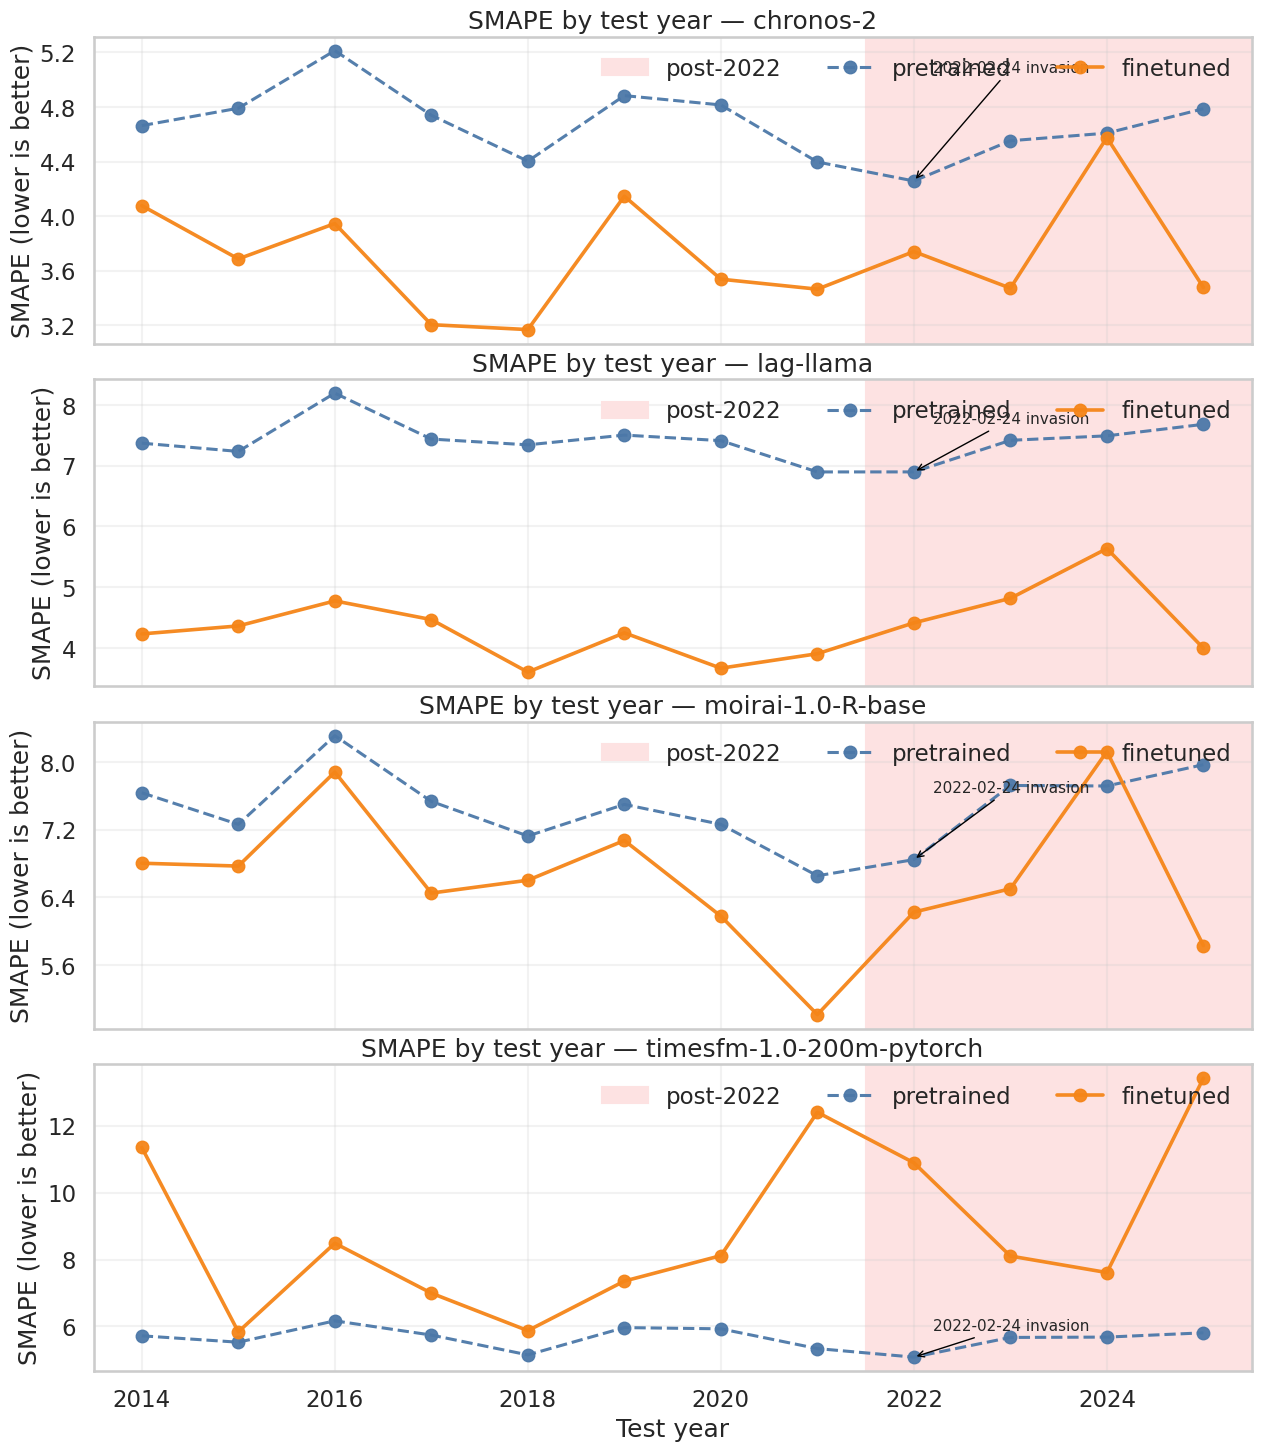

Saved: /local_storage/users/sli0124/diplomovy-projekt/data/results/deep_learning/20260304_224720/plot_delta_smape_by_year_v2.png


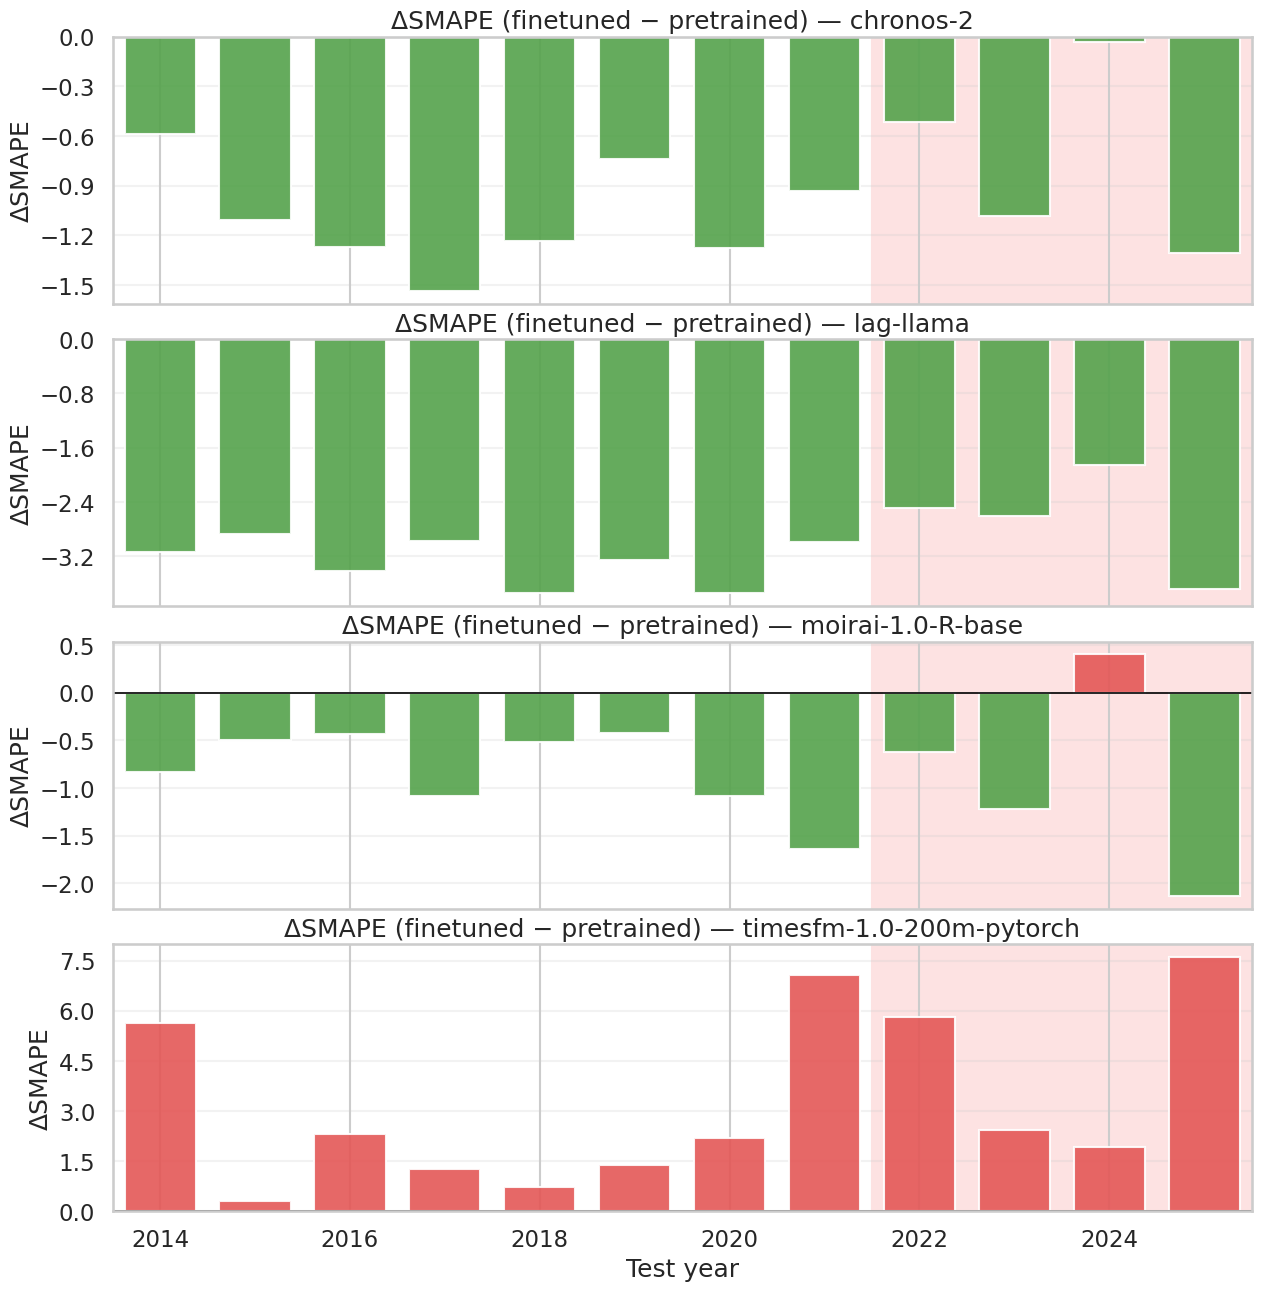

Saved: /local_storage/users/sli0124/diplomovy-projekt/data/results/deep_learning/20260304_224720/plot_delta_smape_heatmap_v2.png


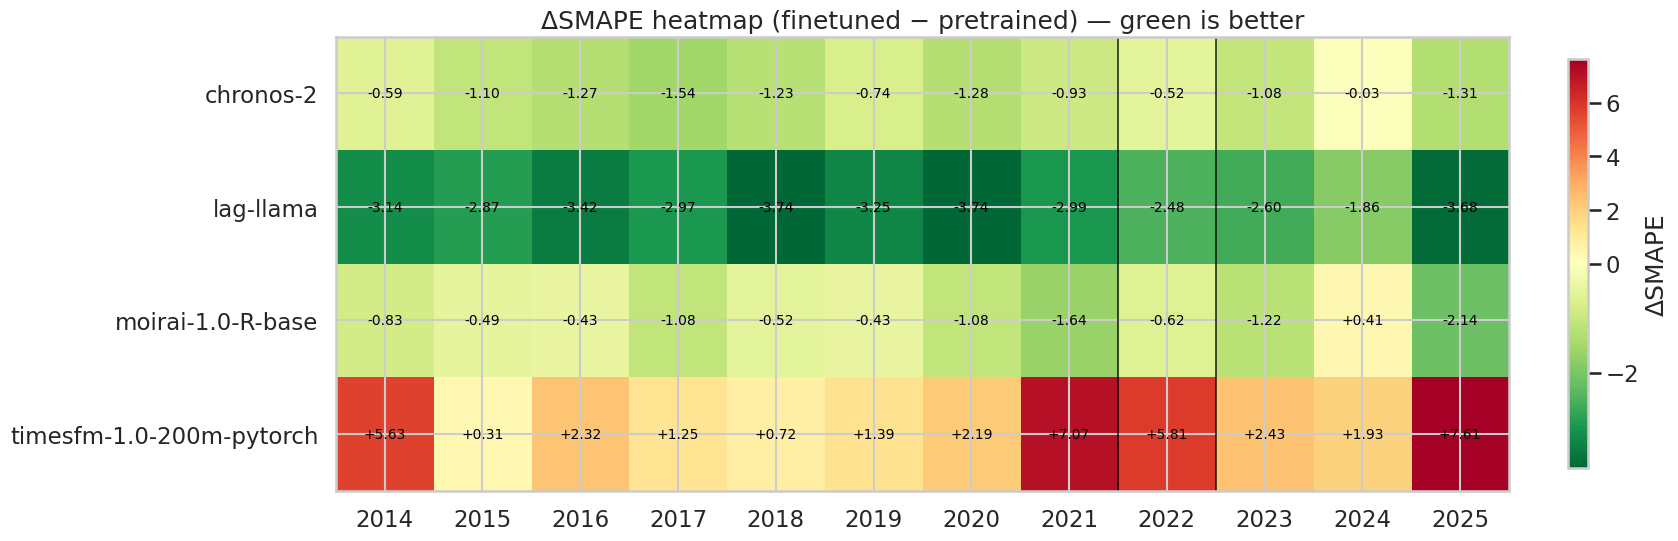

Saved: /local_storage/users/sli0124/diplomovy-projekt/data/results/deep_learning/20260304_224720/plot_smape_pre_post_conflict_grouped_v2.png


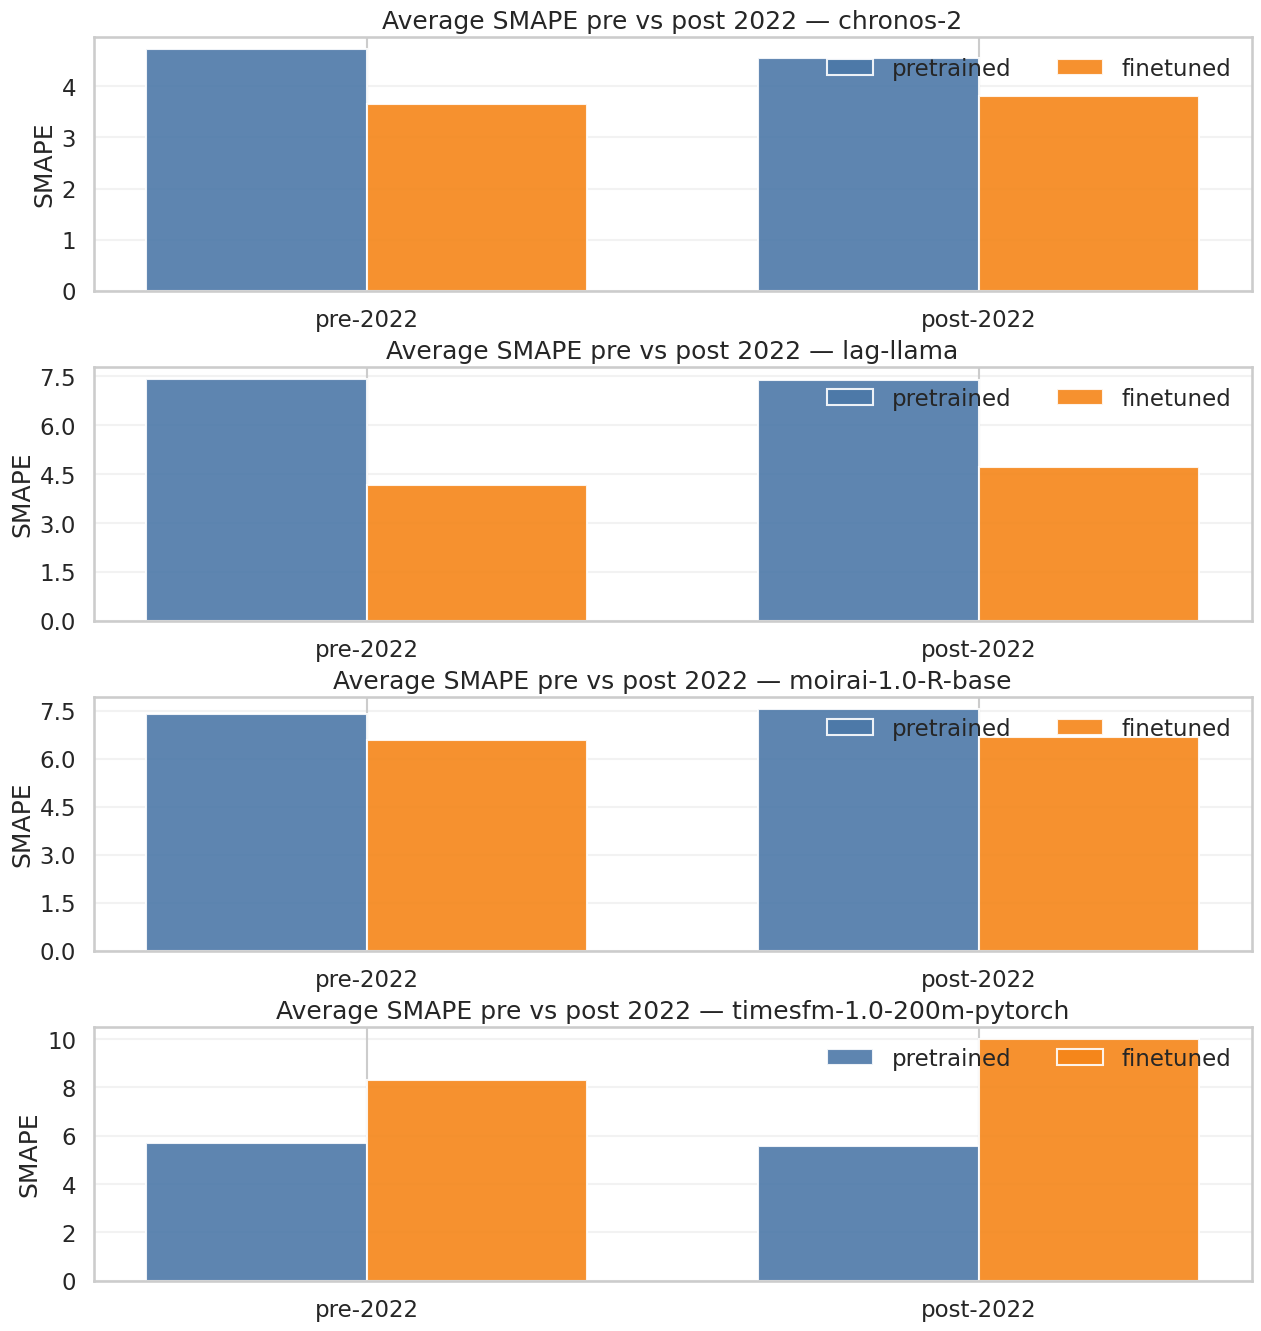

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import MaxNLocator

# Optional nicer defaults if seaborn is installed
try:
    import seaborn as sns  # type: ignore

    sns.set_theme(style="whitegrid", context="talk", palette="colorblind")
    _HAS_SNS = True
except Exception:
    _HAS_SNS = False
    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "axes.grid": True,
            "grid.alpha": 0.25,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.titleweight": "bold",
        }
    )

INVASION_YEAR = 2022
POST_SHADE_COLOR = "#fde2e2"  # light red


def _savefig(fig: plt.Figure, filename: str) -> None:
    path = OUT_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved:", path)


# Ensure comparison_year_smape exists (recompute if needed)
if "comparison_year_smape" not in globals():
    pre_year = all_results[
        (all_results["segment"] == "all") & (all_results["mode"] == "pretrained")
    ][["model", "test_year", "smape", "n_windows"]].rename(
        columns={"smape": "smape_pretrained", "n_windows": "n_windows_pretrained"}
    )
    ft_year = finetuned_results[
        (finetuned_results["segment"] == "all")
        & (finetuned_results["mode"] == "finetuned")
    ][["model", "test_year", "smape", "n_windows"]].rename(
        columns={"smape": "smape_finetuned", "n_windows": "n_windows_finetuned"}
    )
    comparison_year_smape = pre_year.merge(
        ft_year, on=["model", "test_year"], how="inner"
    )
    comparison_year_smape["delta_smape_finetuned_minus_pretrained"] = (
        comparison_year_smape["smape_finetuned"]
        - comparison_year_smape["smape_pretrained"]
    )

plot_df = comparison_year_smape.copy()
plot_df = plot_df.sort_values(["model", "test_year"]).reset_index(drop=True)

models = plot_df["model"].unique().tolist()
years = sorted(plot_df["test_year"].unique().tolist())

# Colors: keep consistent across all plots
MODE_STYLE = {
    "pretrained": {"linestyle": "--", "marker": "o", "linewidth": 2.2, "alpha": 0.95},
    "finetuned": {"linestyle": "-", "marker": "o", "linewidth": 2.6, "alpha": 0.95},
}
MODE_COLOR = {"pretrained": "#4c78a8", "finetuned": "#f58518"}  # blue / orange

# --- Plot 1: SMAPE by year (small multiples), with post-2022 shading ---
fig, axes = plt.subplots(
    nrows=len(models),
    ncols=1,
    figsize=(12.5, 3.6 * len(models)),
    sharex=True,
    constrained_layout=True,
)
if len(models) == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    d = plot_df[plot_df["model"] == model].sort_values("test_year")
    xmin, xmax = min(years) - 0.5, max(years) + 0.5
    ax.axvspan(
        INVASION_YEAR - 0.5, xmax, color=POST_SHADE_COLOR, zorder=0, label="post-2022"
    )

    ax.plot(
        d["test_year"],
        d["smape_pretrained"],
        color=MODE_COLOR["pretrained"],
        label="pretrained",
        **MODE_STYLE["pretrained"],
    )
    ax.plot(
        d["test_year"],
        d["smape_finetuned"],
        color=MODE_COLOR["finetuned"],
        label="finetuned",
        **MODE_STYLE["finetuned"],
    )

    # Mark invasion year explicitly if present
    if (d["test_year"] == INVASION_YEAR).any():
        y_ref = float(
            d.loc[d["test_year"] == INVASION_YEAR, "smape_pretrained"].iloc[0]
        )
        ax.annotate(
            "2022-02-24 invasion",
            xy=(INVASION_YEAR, y_ref),
            xytext=(INVASION_YEAR + 0.2, y_ref + 0.8),
            arrowprops={"arrowstyle": "->", "color": "black", "lw": 1},
            fontsize=11,
        )

    ax.set_title(f"SMAPE by test year — {model}")
    ax.set_ylabel("SMAPE (lower is better)")
    ax.set_xlim(xmin, xmax)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3, frameon=False, loc="upper right")

axes[-1].set_xlabel("Test year")
axes[-1].xaxis.set_major_locator(MaxNLocator(integer=True))
_savefig(fig, "plot_smape_by_year_pretrained_vs_finetuned_v2.png")
plt.show()

# --- Plot 2: ΔSMAPE by year as bars (green=improvement, red=worse) ---
fig2, axes2 = plt.subplots(
    nrows=len(models),
    ncols=1,
    figsize=(12.5, 3.2 * len(models)),
    sharex=True,
    constrained_layout=True,
)
if len(models) == 1:
    axes2 = [axes2]

for ax, model in zip(axes2, models):
    d = plot_df[plot_df["model"] == model].sort_values("test_year")
    xmin, xmax = min(years) - 0.5, max(years) + 0.5
    ax.axvspan(INVASION_YEAR - 0.5, xmax, color=POST_SHADE_COLOR, zorder=0)

    delta = d["delta_smape_finetuned_minus_pretrained"].to_numpy(dtype=float)
    bar_colors = np.where(delta <= 0, "#54a24b", "#e45756")  # green/red
    ax.axhline(0.0, color="black", linewidth=1.2)
    ax.bar(d["test_year"], delta, color=bar_colors, width=0.75, alpha=0.9)

    ax.set_title(f"ΔSMAPE (finetuned − pretrained) — {model}")
    ax.set_ylabel("ΔSMAPE")
    ax.set_xlim(xmin, xmax)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.grid(True, axis="y", alpha=0.25)

axes2[-1].set_xlabel("Test year")
axes2[-1].xaxis.set_major_locator(MaxNLocator(integer=True))
_savefig(fig2, "plot_delta_smape_by_year_v2.png")
plt.show()

# --- Plot 3: Heatmap of ΔSMAPE (model × year) ---
heat = (
    plot_df.pivot(
        index="model",
        columns="test_year",
        values="delta_smape_finetuned_minus_pretrained",
    )
    .reindex(index=models, columns=years)
    .astype(float)
)

fig3, ax3 = plt.subplots(
    figsize=(1.1 * len(years) + 3.5, 0.7 * len(models) + 2.5), constrained_layout=True
)
norm = TwoSlopeNorm(
    vmin=float(np.nanmin(heat.values)), vcenter=0.0, vmax=float(np.nanmax(heat.values))
)
im = ax3.imshow(heat.values, cmap="RdYlGn_r", norm=norm, aspect="auto")

ax3.set_title("ΔSMAPE heatmap (finetuned − pretrained) — green is better")
ax3.set_yticks(np.arange(len(models)))
ax3.set_yticklabels(models)
ax3.set_xticks(np.arange(len(years)))
ax3.set_xticklabels(years, rotation=0)

# Annotate cells (kept readable)
for i in range(len(models)):
    for j in range(len(years)):
        val = heat.values[i, j]
        if np.isnan(val):
            continue
        ax3.text(
            j, i, f"{val:+.2f}", ha="center", va="center", fontsize=10, color="black"
        )

# Mark the invasion-year column
if INVASION_YEAR in years:
    j = years.index(INVASION_YEAR)
    ax3.axvline(j - 0.5, color="black", lw=1.2, alpha=0.8)
    ax3.axvline(j + 0.5, color="black", lw=1.2, alpha=0.8)

cbar = fig3.colorbar(im, ax=ax3, shrink=0.9)
cbar.set_label("ΔSMAPE")
_savefig(fig3, "plot_delta_smape_heatmap_v2.png")
plt.show()

# --- Plot 4: Pre vs post 2022 average SMAPE (grouped bars, pretrained vs finetuned) ---
pre_post_pretrained = (
    all_results[
        (all_results["segment"] == "all") & (all_results["mode"] == "pretrained")
    ]
    .groupby(["model", "period"], as_index=False)
    .agg(smape=("smape", "mean"))
    .assign(mode="pretrained")
)
pre_post_finetuned = (
    finetuned_results[
        (finetuned_results["segment"] == "all")
        & (finetuned_results["mode"] == "finetuned")
    ]
    .groupby(["model", "period"], as_index=False)
    .agg(smape=("smape", "mean"))
    .assign(mode="finetuned")
)
pre_post = pd.concat([pre_post_pretrained, pre_post_finetuned], ignore_index=True)
pre_post["period"] = pd.Categorical(
    pre_post["period"], categories=["pre", "post"], ordered=True
)

fig4, axes4 = plt.subplots(
    nrows=len(models),
    ncols=1,
    figsize=(12.5, 3.3 * len(models)),
    constrained_layout=True,
)
if len(models) == 1:
    axes4 = [axes4]

for ax, model in zip(axes4, models):
    d = pre_post[pre_post["model"] == model].copy()
    d = d.sort_values(["period", "mode"])
    x = np.arange(2)  # pre, post
    width = 0.36

    pre_vals = (
        d[d["mode"] == "pretrained"]
        .sort_values("period")["smape"]
        .to_numpy(dtype=float)
    )
    ft_vals = (
        d[d["mode"] == "finetuned"].sort_values("period")["smape"].to_numpy(dtype=float)
    )

    ax.bar(
        x - width / 2,
        pre_vals,
        width,
        label="pretrained",
        color=MODE_COLOR["pretrained"],
        alpha=0.9,
    )
    ax.bar(
        x + width / 2,
        ft_vals,
        width,
        label="finetuned",
        color=MODE_COLOR["finetuned"],
        alpha=0.9,
    )

    ax.set_title(f"Average SMAPE pre vs post 2022 — {model}")
    ax.set_ylabel("SMAPE")
    ax.set_xticks(x)
    ax.set_xticklabels(["pre-2022", "post-2022"])
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(frameon=False, ncol=2, loc="upper right")

_savefig(fig4, "plot_smape_pre_post_conflict_grouped_v2.png")
plt.show()

In [38]:
%matplotlib inline
from IPython.display import Image

Image(
    "..\\data\\results\\deep_learning\\20260205_225249\\plot_delta_smape_heatmap_v2.png"
)

FileNotFoundError: No such file or directory: '..\data\results\deep_learning\20260205_225249\plot_delta_smape_heatmap_v2.png'

FileNotFoundError: No such file or directory: '..\data\results\deep_learning\20260205_225249\plot_delta_smape_heatmap_v2.png'

<IPython.core.display.Image object>

In [39]:
Image(
    "..\\data\\results\\deep_learning\\20260205_225249\\plot_smape_by_year_pretrained_vs_finetuned_v2.png"
)

FileNotFoundError: No such file or directory: '..\data\results\deep_learning\20260205_225249\plot_smape_by_year_pretrained_vs_finetuned_v2.png'

FileNotFoundError: No such file or directory: '..\data\results\deep_learning\20260205_225249\plot_smape_by_year_pretrained_vs_finetuned_v2.png'

<IPython.core.display.Image object>

In [40]:
Image(
    "..\\data\\results\\deep_learning\\20260205_225249\\plot_delta_smape_by_year_v2.png"
)

FileNotFoundError: No such file or directory: '..\data\results\deep_learning\20260205_225249\plot_delta_smape_by_year_v2.png'

FileNotFoundError: No such file or directory: '..\data\results\deep_learning\20260205_225249\plot_delta_smape_by_year_v2.png'

<IPython.core.display.Image object>

In [41]:
Image(
    "..\\data\\results\\deep_learning\\20260205_225249\\plot_smape_pre_post_conflict_grouped_v2.png"
)

FileNotFoundError: No such file or directory: '..\data\results\deep_learning\20260205_225249\plot_smape_pre_post_conflict_grouped_v2.png'

FileNotFoundError: No such file or directory: '..\data\results\deep_learning\20260205_225249\plot_smape_pre_post_conflict_grouped_v2.png'

<IPython.core.display.Image object>